In [1]:
import wrf

import cartopy.crs as ccrs
from cartopy import geodesic
from cartopy.feature import NaturalEarthFeature, BORDERS, ShapelyFeature, OCEAN, LAND
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.shapereader as shpreader
import cartopy.io.img_tiles as cimgt
import cartopy.feature as cfeature

import netCDF4 as nc
import glob
import numpy as np
import xarray as xr
import rioxarray
import xwrf
import pyart
import zipfile
import datetime as dt
import os
import tqdm
import pandas as pd
import warnings

from metpy.interpolate import cross_section
import shapely
from shapely.geometry.polygon import Polygon, LinearRing
from copy import deepcopy
import pyproj

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.cm import get_cmap
from matplotlib.patches import Rectangle

import plotly.graph_objs as go
from plotly.subplots import make_subplots
import salem

warnings.simplefilter("ignore")

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [11]:
# Paths
path_figs  = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"
path_radar = "g/data/up6/ai2733/Gusts_downdrafts/data/Radar/"
path_wrf   = "/g/data/w28/ai2733/" # WRF outputs

In [12]:
# General info
name_figs   = {"CASE1": "4",
                 "CASE2_new": "5",
                 "CASE3_new": "6"}

date_cases    = {"CASE1": ("2015-12-15", "2015-12-16"), 
                 "CASE2_new": ("2009-01-19","2009-01-20"), 
                 "CASE3_new": ("2017-02-16","2017-02-17")}
lat_lon_cases = {"CASE1": (-29.49, 149.85), 
                "CASE2_new": (-35.16, 147.46), 
                "CASE3_new": (-31.07,150.84)}
station_cases = {"CASE1": "053115", 
                 "CASE2_new": "072150", 
                 "CASE3_new": "055325"}
name_cases    = {"CASE1": "Moree Aero",
                 "CASE2_new": "Wagga Wagga", 
                 "CASE3_new": "Tamworth Airport"}
radar_cases   = {"CASE1": "53",
                 "CASE2_new": "55",
                 "CASE3_new": "69"}
dates_plots  = {"CASE1": ["2015-12-16 05:00", "2015-12-16 09:00"],
           "CASE2_new": ["2009-01-20 03:00", "2009-01-20 08:00"],
           "CASE3_new": ["2017-02-17 05:00", "2017-02-17 10:00"]}


In [7]:
def get_Refl(case, wrf = True):
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    Function to get reflectivity from WRF outputs and closest radar
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    
    # Select case
    domains    = ["d01", "d02", "d03"]
    
    if wrf:
        reflectivity_wrf_filt = {}
        for dom in domains:

            # Open all outputs with xwrf: postprocessing to deal with coords! and destagger all dataset
            # Read 5-minute outputs 
            path_wrf4 = f"{path_wrf}/outputs_{case}/"
            files     = list(np.sort(glob.glob(f"{path_wrf4}wrfout_{dom}_*")))
            wrf_all = xr.open_mfdataset(files, concat_dim = "Time", combine = "nested", chunks = "auto").xwrf.postprocess()
            wrf_all = wrf_all.sortby("Time")
            wrf_all = wrf_all.xwrf.destagger()
            wrf_all["W"].shape

            # Filter dates
            wrf_all = wrf_all.sel(Time = slice(dates_plots[case][0], dates_plots[case][1]))
            # For all domain:
            wrf_all_rad = wrf_all

            # Extent in lat, lon coords
            lat1_dx, lat2_dx = wrf_all_rad.XLAT.min().compute().item(), wrf_all_rad.XLAT.max().compute().item()
            lon1_dx, lon2_dx = wrf_all_rad.XLONG.min().compute().item(), wrf_all_rad.XLONG.max().compute().item()
            extent_plot = [lon1_dx, lon2_dx, lat1_dx, lat2_dx]

            # Reflectivity WRF 
            reflectivity_wrf = wrf_all_rad["REFL_10CM"].max("z")
            reflectivity_wrf_filt[dom] = xr.where(reflectivity_wrf>=20, reflectivity_wrf, np.NaN)

    # Get radar data
    level = "level2"
    var   = "columnmaxreflectivity"
    grid_file = sorted(glob.glob(f"{path_radar}/{radar_cases[case]}/*{radar_cases[case]}*{date_cases[case][1].replace('-', '')}*{var}.nc"))[0]
    # Read tiff with rioxarray and reproject to lat-lon 
    da         = rioxarray.open_rasterio(grid_file)
    lon_origin, lat_origin = da.origin_longitude, da.origin_latitude
    proj_radar = ccrs.AzimuthalEquidistant(central_longitude=lon_origin, central_latitude=lat_origin, false_easting=0., false_northing=0., globe=None) 
    da  = da.rio.write_crs(proj_radar)
    da_lonlat  = da.rio.reproject("EPSG:4326")

    radar_var = da_lonlat[var]
    radar_var = xr.where(radar_var != -9999., radar_var, np.NaN)
    radar_var = radar_var.dropna("time", how = "all")
    radar_var = radar_var.assign_coords({"time":np.array(radar_var.time).astype("datetime64[ns]")})

    reflectivity_radar_filt = xr.where(radar_var>=20, radar_var, np.NaN)
    
    if wrf:
        return reflectivity_wrf_filt, reflectivity_radar_filt, extent_plot, proj_radar
    else:
        return [], reflectivity_radar_filt, [], proj_radar

## Figure 2.2: Radar

In [8]:
cases = ["CASE1", "CASE2_new", "CASE3_new"]

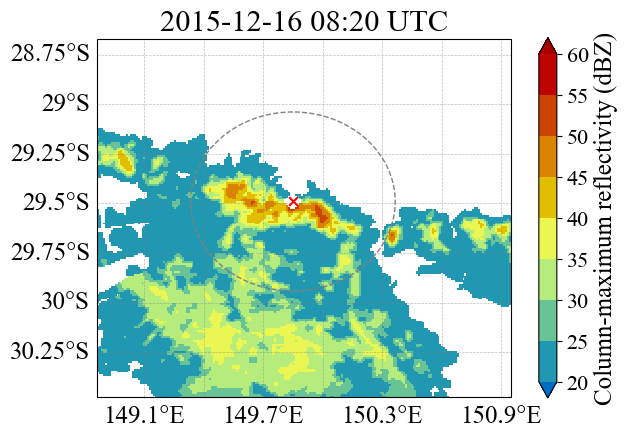

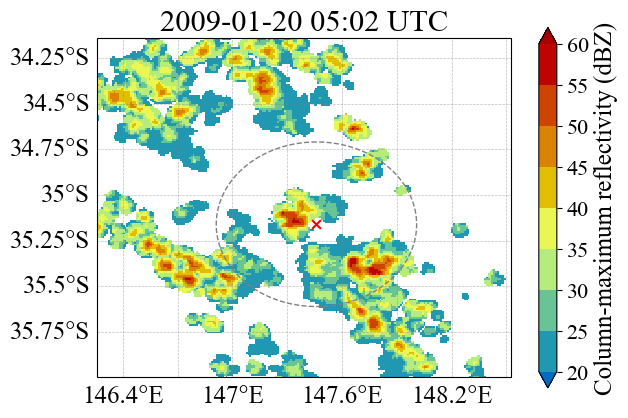

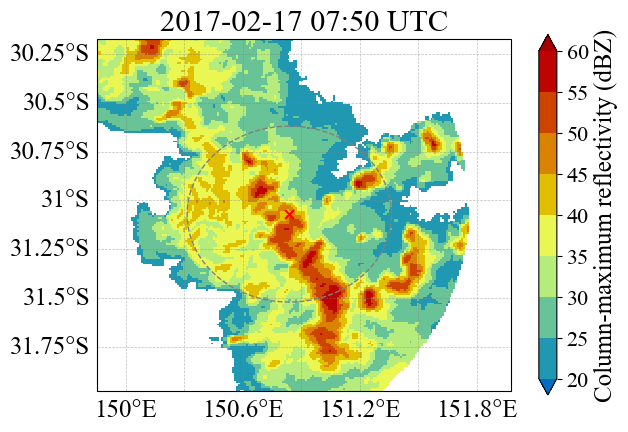

In [9]:
for case in cases:
    ########################
    # Get data to plot
    ########################
    
    reflectivity_wrf_filt, reflectivity_radar_filt, extent_plot, proj_radar = get_Refl(case, wrf = False)
    
    extent_plots = {"CASE1":[148.8626708984375,  150.94888305664062, -30.476078033447266,  -28.668941497802734],
                   "CASE2_new":[146.25860595703125,  148.52517700195312, -35.99697494506836,  -34.14229965209961],
                   "CASE3_new":[149.8541259765625, 151.9764404296875, -31.97750473022461, -30.16958999633789]}
    extent_plot = extent_plots[case]
    
    # Case 2 is at 5:44 UTC but there is none at that time!
    date_max = {"CASE1": "2015-12-16 08:19:00", "CASE2_new": "2009-01-20 05:02:00", "CASE3_new": "2017-02-17 07:48:00"}
    xr_plots = reflectivity_radar_filt.sel(time = date_max[case], method = "nearest")
    
    ########################
    # Plot figure
    ########################

    plt.close("all")
    plt.rcParams.update({
        "font.size": 14+4,            # Controls most text: tick labels, axis labels, legend, etc.
        "axes.titlesize": 18+4,       # Title size for subplots
        "axes.labelsize": 14+4,       # Axis label size
        "xtick.labelsize": 12+4,      # X tick label size
        "ytick.labelsize": 12+4,      # Y tick label size
        "legend.fontsize": 12+4,      # Legend font size
        "figure.titlesize": 18+4,     # Figure-wide title size (if you use `fig.suptitle`),
         "font.family": "Times New Roman",
    })
    fig, ax = plt.subplots(figsize = (6,6), subplot_kw={'projection': ccrs.PlateCarree()})

    levels = np.arange(20, 65, 5)
    im = xr_plots.plot(ax = ax, cmap = "HomeyerRainbow", 
                 levels = levels, vmin = 20, vmax = 60,extend = "both",
                    add_colorbar=False)
    
    try: 
        ax.set_title(str(np.array(xr_plots.Time))[:16].replace("T", " "), fontsize = 8, pad = 0.01)
    except:
        ax.set_title(str(np.array(xr_plots.time))[:16].replace("T", " "), fontsize = 8, pad = 0.01)
    
    # 50 km Rad from AWS
    lat_aws, lon_aws = lat_lon_cases[case]
    r = 50
    circle_points = geodesic.Geodesic().circle(lon_aws, lat_aws, r*1000)
    geom = shapely.geometry.Polygon(circle_points)
    ax.add_geometries((geom,), crs=ccrs.PlateCarree(), facecolor='none', edgecolor="grey", linewidth=1.0, linestyle="--")
    ax.scatter(lon_aws,lat_aws, marker = "x", facecolor = "red", linewidths = 1.5, s = 40.) 
    
    # Nicer
    ax.coastlines(resolution='10m')
    gl = ax.gridlines(crs=ccrs.PlateCarree(), x_inline=False, y_inline=False, draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    
    # To print labels just in border
    if case == "CASE1":
        tol_x, tol_y = 0.15, 0.2 
    elif case == "CASE2_new":
        tol_x, tol_y = 0.19, 0.2 
    else:
        tol_x, tol_y = 0.15, 0.2 
    
    #gl.left_labels = False
    if abs(ax.get_position().y0) < tol_y: 
        gl.bottom_labels = True
    else: 
        gl.bottom_labels = False
    gl.top_labels   = False  # Hide labels on the upper side
    gl.right_labels = False 
    ax.set_title(str(xr_plots.time.to_numpy())[:16].replace("T", " ")+" UTC")#, fontsize = 16)
    ax.set_extent(extent_plot, crs=ccrs.PlateCarree())
        
    # Add a shared colorbar at the bottom
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', shrink = 0.78, fraction=0.05, pad=0.06)
    cbar.set_label('Column-maximum reflectivity (dBZ)', fontsize = 18)
    plt.savefig(f"{path_figs}/Figure2c_{case}.png", dpi = 600, bbox_inches="tight")#, bbox_inches='tight')
    plt.show()

## Figures 4, 5, 6: Radar vs WRF

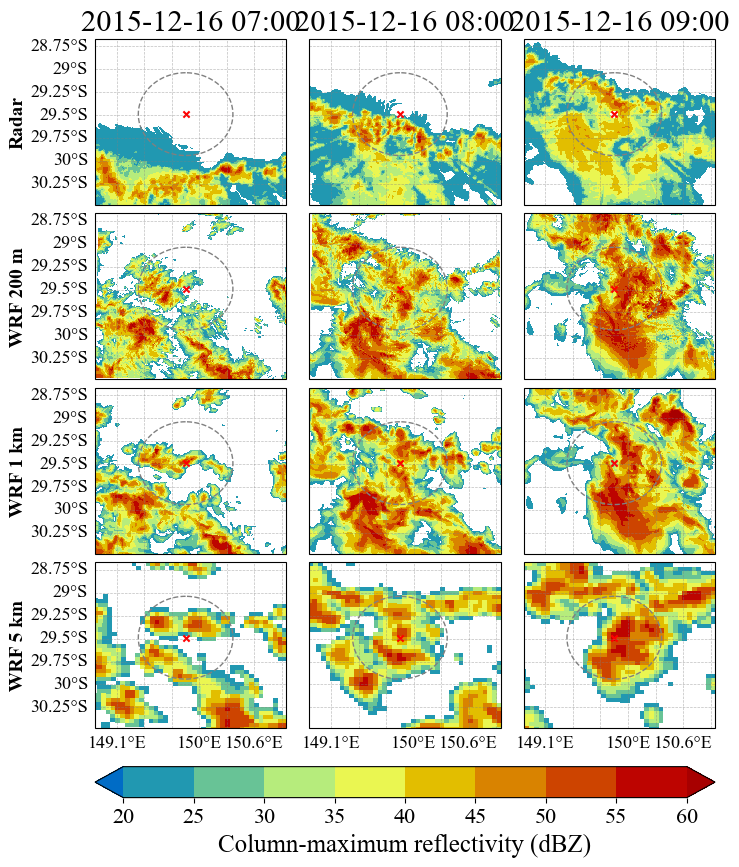

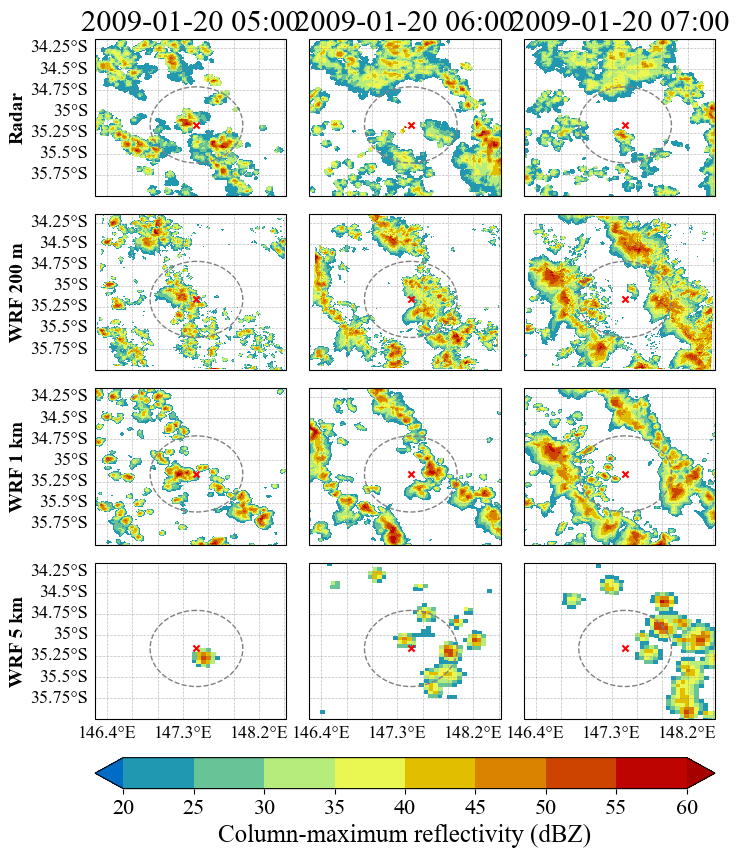

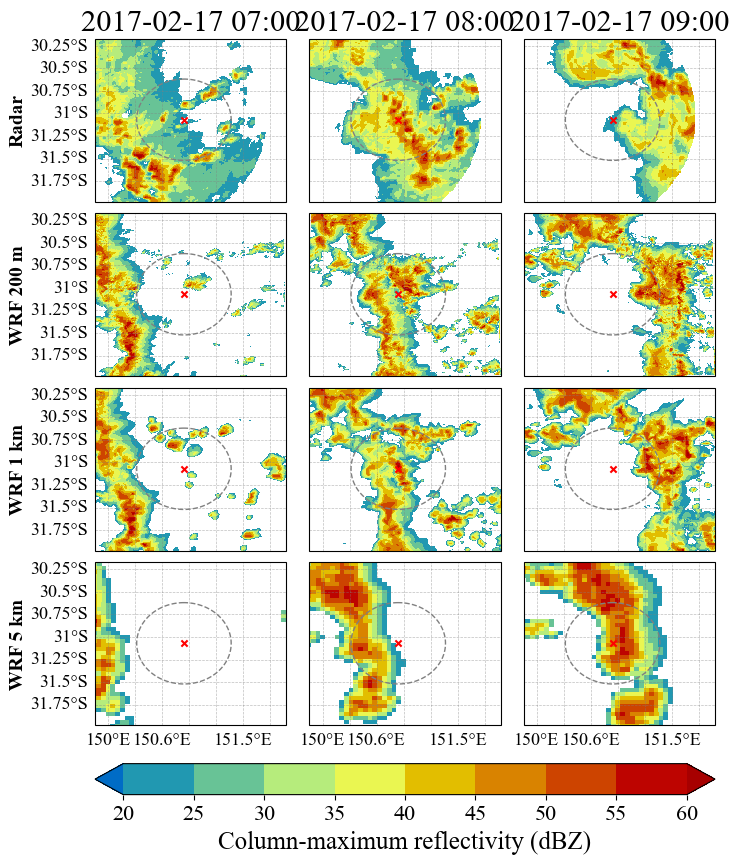

In [10]:
for case in cases:
    # Get data
    reflectivity_wrf_filt, reflectivity_radar_filt, extent_plot, proj_radar = get_Refl(case)

    ########################
    # Get data to plot
    ########################
    
    dates_plots2  = {"CASE1": ["2015-12-16 07:00", "2015-12-16 08:00", "2015-12-16 09:00"],
               "CASE2_new": ["2009-01-20 05:00",  "2009-01-20 06:00", "2009-01-20 07:00"],
               "CASE3_new": ["2017-02-17 07:00", "2017-02-17 08:00", "2017-02-17 09:00"]}
    
    times_range = dates_plots2[case]
    
    # Data to plot
    xr_plots = []
    titles   = []
    for idx, time_ in enumerate(times_range):
        xr_plots.append(reflectivity_radar_filt.sel(time = time_, method = "nearest"))
        titles.append("Radar")
        
    for idx, time_ in enumerate(times_range):
        xr_plots.append(reflectivity_wrf_filt["d03"].sel(Time = time_, method = "nearest").compute())
        titles.append("WRF 200 m")
    
    for idx, time_ in enumerate(times_range):
        xr_plots.append(reflectivity_wrf_filt["d02"].sel(Time = time_, method = "nearest").compute())
        titles.append("WRF 1 km")
    
    for idx, time_ in enumerate(times_range):
        xr_plots.append(reflectivity_wrf_filt["d01"].sel(Time = time_, method = "nearest").compute())
        #print (ref_dom1.sel(Time = time_, method = "bfill").Time)
        titles.append("WRF 5 km")

    ########################
    # Plot figure
    ########################

    savefig = True
    dates = times_range
    
    levels = np.arange(20, 65, 5)
    plt.close("all")
    plt.rcParams.update({"font.size": 13, 
                             "font.family": "Times New Roman"})
    
    fig, axes = plt.subplots(ncols = len(dates), nrows = 4, figsize = (8,10), subplot_kw={'projection': ccrs.PlateCarree()})
    for idx in range(len(xr_plots)):
        ax = axes.flatten()[idx]
        
        if "Radar" in titles[idx]:# == 0: #Radar
            im = xr_plots[idx].plot(ax = ax, cmap = "HomeyerRainbow", 
                         levels = levels, vmin = 20, vmax = 60,extend = "both",
                            add_colorbar=False)
        else: #WRF
            im = xr_plots[idx].plot(x = "XLONG", y = "XLAT", ax = ax, cmap = "HomeyerRainbow", 
             levels = levels, vmin = 20, vmax = 60,extend = "both",add_colorbar=False)
    
        try: 
            ax.set_title(str(np.array(xr_plots[idx].Time))[:16].replace("T", " "), fontsize = 8, pad = 0.01)
        except:
            ax.set_title(str(np.array(xr_plots[idx].time))[:16].replace("T", " "), fontsize = 8, pad = 0.01)
    
        # 50 km Rad from AWS
        lat_aws, lon_aws = lat_lon_cases[case]
        r = 50
        circle_points = geodesic.Geodesic().circle(lon_aws, lat_aws, r*1000)
        geom = shapely.geometry.Polygon(circle_points)
        ax.add_geometries((geom,), crs=ccrs.PlateCarree(), facecolor='none', edgecolor="grey", linewidth=1.0, linestyle="--")
        ax.scatter(lon_aws,lat_aws, marker = "x", facecolor = "red", linewidths = 1.5, s = 20.) 
    
        # Nicer
        ax.coastlines(resolution='10m')
        gl = ax.gridlines(crs=ccrs.PlateCarree(), x_inline=False, y_inline=False, draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        # To print labels just in border
        if case == "CASE1":
            tol_x, tol_y = 0.15, 0.2 
        elif case == "CASE2_new":
            tol_x, tol_y = 0.19, 0.2 
        else:
            tol_x, tol_y = 0.15, 0.2 
        #print (ax.get_position().x0, ax.get_position().y0)
        if abs(ax.get_position().x0) < tol_x: 
            gl.left_labels = True
            ax.text(-0.4, 0.5, titles[idx], horizontalalignment='center', verticalalignment='center',
                    rotation='vertical', transform=ax.transAxes, fontweight = "bold", fontsize = 14)
        else: 
            gl.left_labels = False
        if abs(ax.get_position().y0) < tol_y: 
            gl.bottom_labels = True
        else: 
            gl.bottom_labels = False
        gl.top_labels   = False  # Hide labels on the upper side
        gl.right_labels = False 
        if idx in [0,1, 2]: ax.set_title(dates[idx])
        else:ax.set_title("")
        
        ax.set_extent(extent_plot, crs=ccrs.PlateCarree())
    
    plt.subplots_adjust(hspace=0.03, wspace=0.12)
    
    # Add a shared colorbar at the bottom
    cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05)
    cbar.set_label('Column-maximum reflectivity (dBZ)')
    cbar.set_ticks(levels)  # ensure ticks match the intervals
    
    plt.savefig(f"{path_figs}/Figure{name_figs[case]}.png", dpi = 600, bbox_inches="tight")#, bbox_inches='tight')
    plt.show()        
